# Neutron / X-ray Dual-Modality Tomography Simulation
## Bimodal Histogram Analysis — Tutorial v3

This notebook walks through the complete `neutron_xray_sim` pipeline:

| § | Topic |
|---|-------|
| 0 | Setup & imports |
| 1 | Material database |
| 2 | Phantom construction |
| 3 | Forward projection |
| 4 | Artifact configuration |
| 5 | CT reconstruction (all algorithms) |
| 6 | Bimodal histogram analysis |
| 6b | Volume segmentation |
| 7 | High-level simulation orchestrator |
| 8 | Misalignment sweep |
| 9 | Batch runs |
| **10** | **File-system cache — save & reload every pipeline stage** |
| **11** | **Artifact survey (all algorithms, metrics embedded)** |
| **12** | **Cross-algorithm bimodal histogram grid** |
| **13** | **Cluster-quality metrics & algorithm ranking** |
| 14 | Save figures |

> **v3 changes:** sections 10–13 are new; §5 shows all nine algorithms;
> §7 adds `cache_dir`; §10 demonstrates `SimCache` save/reload;
> §11 uses the updated `run_artifact_survey` with embedded DB/CE metrics;
> §12 uses `plot_cross_algorithm_grid`; §13 uses `compare_algorithms`.


## Corrections applied (v1.1 → v3)

* **Sample size** 10 cm → 1 cm (`voxel_cm = 1/N`).
* **Neutron μ**: imaging-effective values (Lehmann 2010, Boillat 2018) replace total cross-sections.
* **FBP shadow bug**: custom numpy back-projector replaced by `skimage.iradon`.
* **Nine reconstruction algorithms** now available: FBP, GRIDREC, SIRT, SART, CGLS, EM, OSSART, TV_MIN, NESTEROV_SIRT.
* **File-system cache** (`SimCache`): every stage saved as `.npy` automatically.
* **Artifact survey** now returns metrics and embeds DB/CE in panel titles.
* **`plot_cross_algorithm_grid`**: compare mixed-algorithm combinations on the bimodal histogram.


---
## 0 · Setup


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('neutron_xray_sim').parent.resolve()))

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 10})
%matplotlib inline

import neutron_xray_sim as nxs
from neutron_xray_sim.io import SimCache
from neutron_xray_sim.histogram import (
    plot_cross_algorithm_grid,
    make_cross_algorithm_sinos,
    evaluate_histogram_quality,
    compare_algorithms,
)

print(f'neutron_xray_sim v{nxs.__version__} loaded.')
print('Available algorithms:', nxs.AVAILABLE_ALGORITHMS)
print('Available phantoms:  ', list(nxs.PHANTOM_PRESETS.keys()))


neutron_xray_sim v1.0.0 loaded.
Available algorithms: ['FBP', 'GRIDREC', 'SIRT', 'SART', 'CGLS', 'EM', 'OSSART', 'TV_MIN', 'NESTEROV_SIRT']
Available phantoms:   ['composite', 'battery', 'bone_implant', 'industrial']


---
## 1 · Material Database


Every material stores:
- **`mu_n`** — total thermal-neutron linear attenuation [cm⁻¹]
- **`_mu_x_table`** — X-ray μ at 13 energies (NIST XCOM, 20–300 keV)
- **`rho`** — mass density [g/cc]


In [2]:
print(f"{'Material':<18} {'ρ (g/cc)':>10} {'μ_n (cm⁻¹)':>12} {'μ_x @80keV':>12}")
print('─' * 58)
for name, mat in nxs.MATERIALS.items():
    print(f"{name:<18} {mat.rho:>10.3f} {mat.mu_n:>12.4f} {mat._mu_x_table[6]:>12.4f}")


Material             ρ (g/cc)   μ_n (cm⁻¹)   μ_x @80keV
──────────────────────────────────────────────────────────
air                     0.001       0.0000       0.0001
water                   1.000       1.3800       0.1840
aluminum                2.700       0.0980       0.2780
hdpe                    0.950       2.1800       0.1670
iron                    7.870       1.1600       4.1200
titanium                4.510       0.6400       1.4800
copper                  8.960       1.1200       4.9200
lead                   11.350       0.3730      22.8000
bone                    1.920       0.5600       0.4690
tungsten               19.300       1.5600      88.0000
zinc                    7.130       0.3500       3.2500


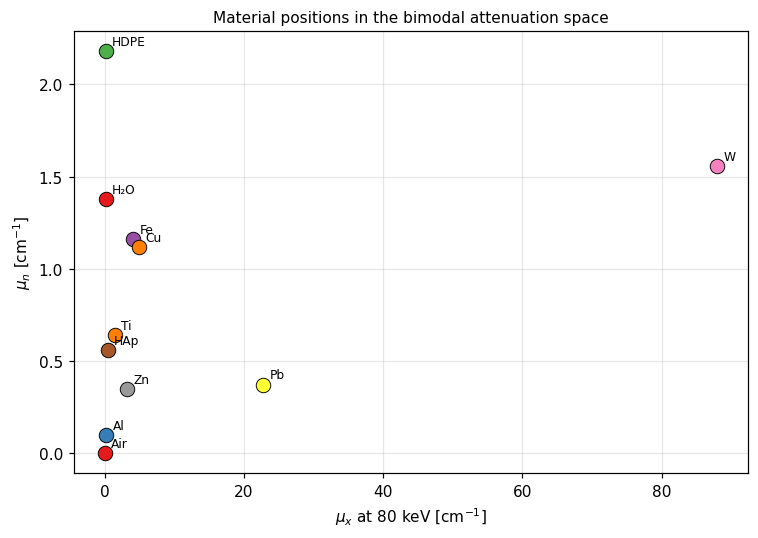

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
colours = plt.cm.Set1(np.linspace(0, 0.9, len(nxs.MATERIALS)))
for (name, mat), col in zip(nxs.MATERIALS.items(), colours):
    ax.scatter(mat._mu_x_table[6], mat.mu_n, s=90, color=col,
               edgecolors='k', linewidths=0.6, zorder=3)
    ax.annotate(mat.symbol, (mat._mu_x_table[6], mat.mu_n),
                xytext=(4, 4), textcoords='offset points', fontsize=8)
ax.set_xlabel(r'$\mu_x$ at 80 keV [cm$^{-1}$]'); ax.set_ylabel(r'$\mu_n$ [cm$^{-1}$]')
ax.set_title('Material positions in the bimodal attenuation space')
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


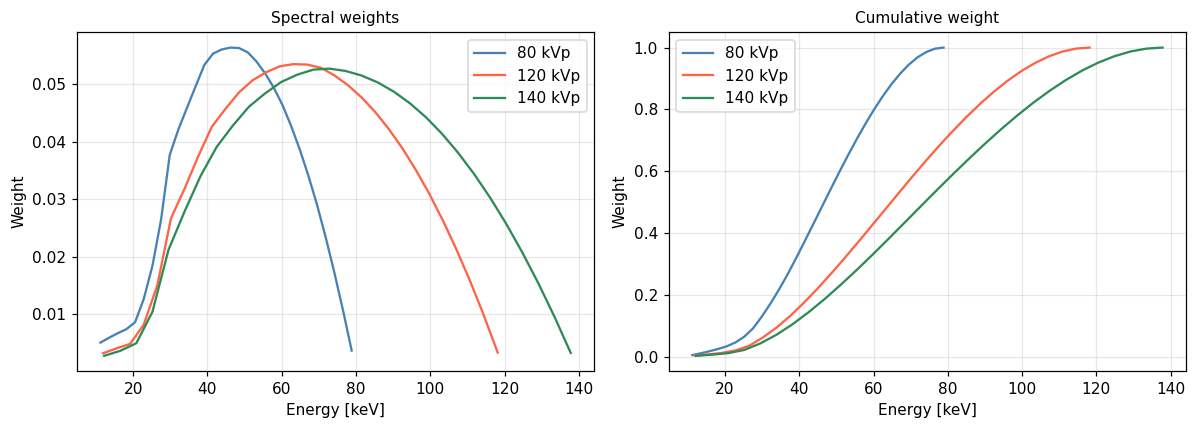

In [4]:
# X-ray spectrum visualisation
from neutron_xray_sim.materials import xray_spectrum
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for kVp, col in [(80, 'steelblue'), (120, 'tomato'), (140, 'seagreen')]:
    E, W = xray_spectrum(kVp, filter_mm_Al=2.0, n_bins=30)
    axes[0].plot(E, W, label=f'{kVp} kVp', color=col)
    axes[1].plot(E, np.cumsum(W), label=f'{kVp} kVp', color=col)
for ax, title in zip(axes, ['Spectral weights', 'Cumulative weight']):
    ax.set_xlabel('Energy [keV]'); ax.set_ylabel('Weight'); ax.legend()
    ax.set_title(title); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## 2 · Phantom Construction


Four preset phantoms are available: `composite`, `battery`, `bone_implant`, `industrial`.
Change `PRESET` and `N` to explore different objects.


In [5]:
# ── Global simulation parameters (shared by all sections below) ──────────
PRESET   = 'composite'   # 'composite' | 'battery' | 'bone_implant' | 'industrial'
N        = 128            # voxel grid (use 128–512 for publication quality)
N_ANGLES = 200           # projection angles (use 360–1200 for publication)

phantom = nxs.make_phantom(PRESET, N)
print(phantom)
print('Materials:', [m.name for m in phantom.materials])


PhantomData('composite', 128³, 0.0078125 cm/voxel, materials=[Air, Al, HDPE, H₂O, Fe, Ti])
Materials: ['Air', 'Aluminum', 'HDPE', 'Water', 'Iron', 'Titanium']


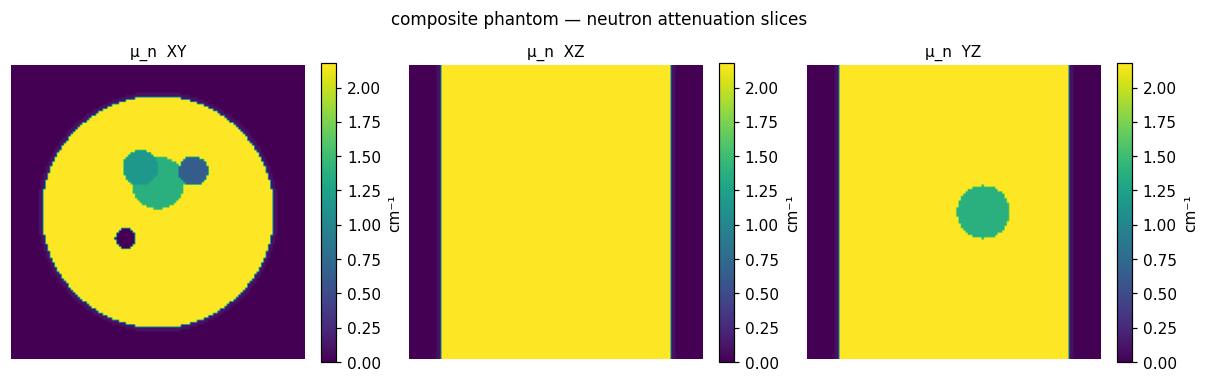

In [6]:
# ── Central orthogonal slices of the neutron attenuation volume ──────────
si = N // 2
slices = [
    ('μ_n  XY', phantom.mu_n_vol[si, :, :]),
    ('μ_n  XZ', phantom.mu_n_vol[:, si, :]),
    ('μ_n  YZ', phantom.mu_n_vol[:, :, si]),
]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for ax, (title, sl) in zip(axes, slices):
    im = ax.imshow(sl, cmap='viridis', origin='lower')
    ax.set_title(title, fontsize=10); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, label='cm⁻¹')
fig.suptitle(f'{PRESET} phantom — neutron attenuation slices', fontsize=11)
plt.tight_layout(); plt.show()


---
## 3 · Forward Projection


X-ray: polychromatic Beer-Lambert sum (beam hardening emerges naturally).
Neutron: three-component thermal model (absorption + coherent + incoherent scatter).


In [7]:
KVP       = 120.0
AL_FILTER = 2.0

xray_sino, neut_sino = nxs.make_sinogram_pair(
    phantom,
    n_angles        = N_ANGLES,
    angle_range_deg = 180.0,
    kVp             = KVP,
    filter_mm_Al    = AL_FILTER,
    n_spectrum_bins = 12,
    I0_xray         = 1e5,
    I0_neutron      = 1e5,
    use_astra       = True,
)
print('X-ray sinogram :', xray_sino['sino_lam'].shape,
      '  (n_angles, N_slice, N_det)')
print('Neutron sinogram:', neut_sino['sino_lam'].shape)


[projector] Projecting 200 angles (ASTRA GPU) …
  → X-ray (polychromatic) …
  → Neutron (thermal) …
[projector] Done.
X-ray sinogram : (200, 128, 128)   (n_angles, N_slice, N_det)
Neutron sinogram: (200, 128, 128)


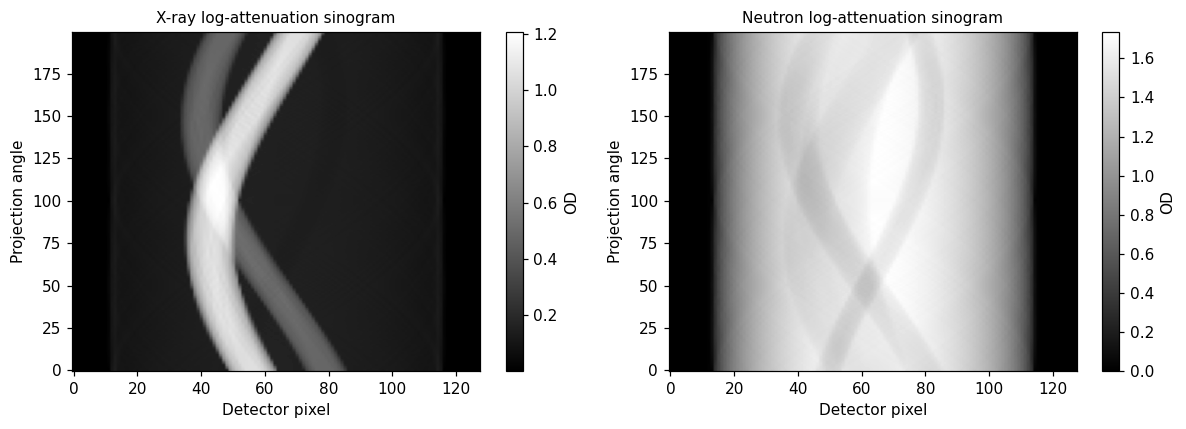

In [8]:
# ── Visualise central sinogram slices ─────────────────────────────────────
s = N // 2
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, sino, title in zip(axes,
        [xray_sino['sino_lam'][:, s, :], neut_sino['sino_lam'][:, s, :]],
        ['X-ray log-attenuation sinogram', 'Neutron log-attenuation sinogram']):
    im = ax.imshow(sino, aspect='auto', cmap='gray', origin='lower')
    ax.set_xlabel('Detector pixel'); ax.set_ylabel('Projection angle')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='OD')
plt.tight_layout(); plt.show()


---
## 4 · Artifact Configuration


| Flag | Domain | Bimodal histogram signature |
|------|--------|-----------------------------|
| `photon_noise` | sino | Cluster broadening; blobs merge at low I₀ |
| `apply_bh_correction=False` | sino | μ_x cupping — dense clusters shift left |
| `neutron_scatter` | sino | All clusters shift up along μ_n |
| `xray_scatter` | sino | All clusters shift left along μ_x |
| `detector_psf` | sino | Cluster broadening; stronger in μ_n |
| `ring_artifacts` | sino | Vertical stripes at specific μ_x values |
| `misalignment` | vol | Horizontal streaks at each material's μ_n |


In [ ]:
configs_demo = [
    nxs.ArtifactConfig.clean(),
    nxs.ArtifactConfig.noise_only(I0=5e4),
    nxs.ArtifactConfig.scatter_only(),
    nxs.ArtifactConfig.misalignment_only(),
    nxs.ArtifactConfig.realistic(),
]
for cfg in configs_demo:
    print(cfg.summary())


In [ ]:
# ── Custom config ─────────────────────────────────────────────────────────
custom_cfg = nxs.ArtifactConfig(
    photon_noise              = True,
    I0_xray                   = 5e4,
    I0_neutron                = 5e4,
    neutron_scatter           = True,
    scatter_fraction          = 0.06,
    scatter_sigma_pixels      = 9.0,
    detector_psf              = True,
    psf_sigma_xray_pixels     = 0.8,
    psf_sigma_neutron_pixels  = 1.5,
)
print('Custom config:', custom_cfg.summary())


---
## 5 · CT Reconstruction


Nine algorithms are available. Select one with `ALGORITHM` below.

| Algorithm | Type | GPU | Notes |
|-----------|------|-----|-------|
| `FBP` | analytic | optional | Fast; ramp filter; ringing artefacts |
| `GRIDREC` | analytic | no | Fourier gridding; needs TomoPy |
| `SIRT` | iterative | yes | Best H₂O/HDPE separation |
| `SART` | iterative | yes | Recommended default |
| `CGLS` | iterative | yes | Fast; needs regularisation |
| `EM` | iterative | yes | ML-EM; enforces positivity |
| `OSSART` | iterative | yes | Ordered-subset SART; fastest iterative |
| `TV_MIN` | iterative | yes | Total-variation; piecewise-constant |
| `NESTEROV_SIRT` | iterative | yes | Nesterov momentum; ~1.7× faster than SIRT |

```python
from neutron_xray_sim import AVAILABLE_ALGORITHMS
print(AVAILABLE_ALGORITHMS)
```


In [ ]:
from neutron_xray_sim.artifacts import inject_sinogram_artifacts, inject_volume_artifacts

# ── Inject sinogram-domain artifacts ──────────────────────────────────────
x_sino_art, n_sino_art = inject_sinogram_artifacts(
    {k: v.copy() if isinstance(v, np.ndarray) else v for k, v in xray_sino.items()},
    {k: v.copy() if isinstance(v, np.ndarray) else v for k, v in neut_sino.items()},
    custom_cfg,
)


In [ ]:
# ── Choose algorithm and reconstruct ──────────────────────────────────────
ALGORITHM   = 'SART'         # change to any of the nine algorithms above
FILTER_NAME = 'shepp-logan'  # for FBP / GRIDREC only
N_ITER      = 30             # for all iterative algorithms
N_SUBSETS   = 10             # for OSSART only
LAMBDA_TV   = 0.02           # for TV_MIN only

vol_x, vol_n = nxs.reconstruct_pair(
    x_sino_art, n_sino_art,
    algorithm    = ALGORITHM,
    filter_name  = FILTER_NAME,
    n_iter       = N_ITER,
    n_subsets    = N_SUBSETS,
    lambda_tv    = LAMBDA_TV,
    remove_rings = True,
    use_astra    = True,
    clip_negative= True,
)

# Apply volume-domain artifacts (misalignment etc.)
vol_x, vol_n = inject_volume_artifacts(vol_x, vol_n, custom_cfg)

print(f'vol_x: {vol_x.shape}  [{vol_x.min():.3f}, {vol_x.max():.3f}] cm⁻¹')
print(f'vol_n: {vol_n.shape}  [{vol_n.min():.3f}, {vol_n.max():.3f}] cm⁻¹')


In [ ]:
# ── Reconstructed central slices ──────────────────────────────────────────
si = N // 2
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for col, (vx_sl, vn_sl, lbl) in enumerate([
        (vol_x[si],       vol_n[si],       'XY'),
        (vol_x[:, si, :], vol_n[:, si, :], 'XZ'),
        (vol_x[:, :, si], vol_n[:, :, si], 'YZ'),
]):
    vmin_x, vmax_x = np.percentile(vol_x, [1, 99])
    vmin_n, vmax_n = np.percentile(vol_n, [1, 99])
    axes[0, col].imshow(vx_sl, cmap='gray', vmin=vmin_x, vmax=vmax_x)
    axes[0, col].set_title(f'X-ray {lbl} — {ALGORITHM}'); axes[0, col].axis('off')
    axes[1, col].imshow(vn_sl, cmap='gray', vmin=vmin_n, vmax=vmax_n)
    axes[1, col].set_title(f'Neutron {lbl} — {ALGORITHM}'); axes[1, col].axis('off')
plt.tight_layout(); plt.show()


---
## 6 · Bimodal Histogram Analysis


The joint 2-D histogram H(μ_x, μ_n) is the diagnostic core.
Pure-material voxels form compact Gaussian clusters; interface voxels trace
straight partial-volume bridges between adjacent cluster centres.


In [ ]:
hist = nxs.compute_bimodal_histogram(vol_x, vol_n, bins=128)
print(f'Histogram shape: {hist.H.shape}  total voxels: {hist.total_voxels:,}')


In [ ]:
# Ground truth vs reconstruction
gt_hist = nxs.compute_ground_truth_histogram(phantom, bins=128)
fig = nxs.plot_ground_truth_comparison(
    phantom, hist,
    title_gt    = 'Ground Truth (exact positions)',
    title_recon = f'Reconstructed — {ALGORITHM}',
    show_marginals = True,
)
plt.show()


In [ ]:
# Single histogram with marginals
fig = nxs.plot_bimodal_histogram(
    hist,
    title          = f'Bimodal histogram — {PRESET} / {ALGORITHM}',
    show_marginals = True,
    log_scale      = True,
)
plt.show()


In [ ]:
# GMM fitting
n_true = len(phantom.materials)
gmm = nxs.auto_fit_gmm(hist, min_k=max(2, n_true-1), max_k=n_true+2)
print(f'GMM: k={gmm.n_components}  BIC={gmm.bic:.0f}  AIC={gmm.aic:.0f}')

fig = nxs.plot_bimodal_histogram(
    hist, gmm=gmm,
    title=f'Bimodal histogram + GMM ({gmm.n_components} components)',
    show_marginals=True,
)
plt.show()


In [ ]:
# Artifact signature metrics
sigs = nxs.detect_artifact_signatures(hist)
print(f'Horizontal streak (misalignment proxy) : {sigs.horizontal_streak_score:.4f}')
print(f'Vertical streak   (ring artifact proxy) : {sigs.vertical_streak_score:.4f}')
print(f'Diagonal smear    (BH / scatter proxy)  : {sigs.diagonal_smear_score:.4f}')
print(f'μ_n shift         (neutron scatter)     : {sigs.marginal_shift_n:.4f} cm⁻¹')


---
## 6b · Volume Segmentation from Histogram


In [ ]:
label_vol = nxs.segment_by_gmm(vol_x, vol_n, gmm)
gt_labels = phantom.label_vol

si = N // 2
cmap_seg = plt.cm.get_cmap('tab10', gmm.n_components)
cmap_gt  = plt.cm.get_cmap('tab10', n_true)

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for col, lbl in enumerate(['XY', 'XZ', 'YZ']):
    idx = (si, slice(None), slice(None)) if lbl == 'XY' else \
          (slice(None), si, slice(None)) if lbl == 'XZ' else \
          (slice(None), slice(None), si)
    axes[0, col].imshow(gt_labels[idx], cmap=cmap_gt,
                        vmin=0, vmax=n_true-1)
    axes[0, col].set_title(f'GT labels {lbl}'); axes[0, col].axis('off')
    axes[1, col].imshow(label_vol[idx], cmap=cmap_seg,
                        vmin=0, vmax=gmm.n_components-1)
    axes[1, col].set_title(f'GMM labels {lbl}'); axes[1, col].axis('off')
fig.suptitle('Ground-truth vs GMM segmentation', fontsize=11)
plt.tight_layout(); plt.show()


---
## 7 · High-Level Simulation Orchestrator


`DualModalitySimulation` manages the full pipeline in one object.
Raw sinograms are computed **once** and cached so subsequent runs with
different artifact configs reuse them.

**New in v3:** pass `cache_dir` to persist every stage to disk automatically.
See §10 for the full cache workflow.


In [ ]:
# ── Create simulation (with optional disk cache) ──────────────────────────
sim = nxs.DualModalitySimulation(
    preset    = PRESET,
    N         = N,
    n_angles  = N_ANGLES,
    algorithm = 'SART',
    auto_gmm  = False,
    verbose   = True,
    # cache_dir = 'results/composite_SART',  # ← enable to save to disk
)


In [ ]:
r_clean   = sim.run(nxs.ArtifactConfig.clean(),           tag='clean')
r_noise   = sim.run(nxs.ArtifactConfig.noise_only(I0=5e4), tag='noise_moderate')
r_scatter = sim.run(nxs.ArtifactConfig.scatter_only(),     tag='scatter')
r_misalign= sim.run(
    nxs.ArtifactConfig(misalignment=True,
                       translation_voxels=(3, 0, 0)),
    tag='misalign_3vx',
)
r_real    = sim.run(nxs.ArtifactConfig.realistic(),         tag='realistic')


In [ ]:
# ── Comparison grid ───────────────────────────────────────────────────────
all_results = [r_clean, r_noise, r_scatter, r_misalign, r_real]
fig = sim.comparison_grid(all_results, ncols=3)
plt.show()


In [ ]:
# ── Slice comparison ──────────────────────────────────────────────────────
fig = sim.comparison_slices(all_results)
plt.show()


In [ ]:
# ── Artifact signature table ──────────────────────────────────────────────
print(sim.signature_table(all_results))


---
## 8 · Misalignment Sweep


In [ ]:
DISPLACEMENTS = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0, 8.0]   # voxels

sim_sweep = nxs.DualModalitySimulation(
    preset=PRESET, N=N, n_angles=N_ANGLES,
    algorithm='SART', verbose=False,
)

sweep_results = []
ref_r = sim_sweep.run(nxs.ArtifactConfig.clean(), tag='0 vx (clean)')
sweep_results.append(ref_r)

for d in DISPLACEMENTS[1:]:
    cfg_d = nxs.ArtifactConfig(
        misalignment=True,
        translation_voxels=(d, 0.0, 0.0),
    )
    r = sim_sweep.run(cfg_d, tag=f'{d:.1f} vx', ref_result=ref_r)
    sweep_results.append(r)


In [ ]:
# ── Streak score vs displacement ──────────────────────────────────────────
scores = [r.signatures.horizontal_streak_score for r in sweep_results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(DISPLACEMENTS, scores, 'o-', color='tomato', lw=2, ms=7)
ax1.set_xlabel('Translation misalignment [voxels]')
ax1.set_ylabel('Horizontal streak score')
ax1.set_title('Streak score vs misalignment')
ax1.grid(True, alpha=0.3)

# Overlay the 0-vx and 3-vx histograms for comparison
for r, col, lbl in [
        (sweep_results[0], 'steelblue', '0 vx'),
        (sweep_results[DISPLACEMENTS.index(3.0)], 'tomato', '3 vx'),
]:
    H = r.histogram.H.T
    H = np.log1p(np.ma.masked_where(H == 0, H))
    ax2.contour(H, levels=6, colors=[col], alpha=0.7,
                extent=r.histogram.extent)
    ax2.plot([], [], color=col, label=lbl)
ax2.set_xlabel(r'$\mu_x$ [cm$^{-1}$]'); ax2.set_ylabel(r'$\mu_n$ [cm$^{-1}$]')
ax2.set_title('Histogram contours: 0 vx vs 3 vx')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## 9 · Batch Runs


In [ ]:
batch_configs = [
    ('clean',            nxs.ArtifactConfig.clean()),
    ('noise high',       nxs.ArtifactConfig(photon_noise=True, I0_xray=1e4, I0_neutron=1e4)),
    ('noise low',        nxs.ArtifactConfig(photon_noise=True, I0_xray=5e3, I0_neutron=5e3)),
    ('beam hardening',   nxs.ArtifactConfig(apply_bh_correction=False)),
    ('BH corrected',     nxs.ArtifactConfig(apply_bh_correction=True)),
    ('n scatter mild',   nxs.ArtifactConfig(neutron_scatter=True, scatter_fraction=0.04)),
    ('n scatter strong', nxs.ArtifactConfig(neutron_scatter=True, scatter_fraction=0.12)),
    ('rings',            nxs.ArtifactConfig(ring_artifacts=True, n_bad_columns=4)),
    ('psf',              nxs.ArtifactConfig(detector_psf=True, psf_sigma_neutron_pixels=2.5)),
    ('misalign 3vx',     nxs.ArtifactConfig(misalignment=True, translation_voxels=(3,0,0))),
    ('realistic',        nxs.ArtifactConfig.realistic()),
]

sim_batch = nxs.DualModalitySimulation(
    preset=PRESET, N=N, n_angles=N_ANGLES,
    algorithm='SART', verbose=False,
)
batch_results = sim_batch.run_batch(batch_configs, ref_tag='clean')
print('Batch done. Runs:', list(batch_results.keys()))


In [ ]:
print(sim_batch.signature_table())


In [ ]:
fig = sim_batch.comparison_grid(ncols=4,
    suptitle=f'Batch artifact survey — {PRESET} / SART')
plt.show()


---
## 10 · File-System Cache — Save and Reload Every Pipeline Stage  ★ new in v3


The `SimCache` class saves every pipeline stage as `.npy` files.
On the next run, expensive steps (phantom build, GPU projection,
iterative reconstruction) are skipped if the files already exist.

**Directory layout:**
```
results/composite_SART/
├── phantom/               label_vol.npy, mu_x_vol_*.npy, mu_n_*_vol.npy, meta.json
├── sinograms/             xray_sino_lam.npy, neutron_sino_lam.npy, sino_meta.json
└── runs/
    └── clean/             vol_xray.npy, vol_neutron.npy,
                           histogram_H.npy, histogram_*edges.npy, run_meta.json
```

After the survey is saved you can reload any stage independently
and re-run only the analysis — no GPU required.


In [ ]:
CACHE_DIR = 'results/composite_SART_cache'

# ── Run with cache enabled ─────────────────────────────────────────────────
sim_cached = nxs.DualModalitySimulation(
    preset    = PRESET,
    N         = N,
    n_angles  = N_ANGLES,
    algorithm = 'SART',
    verbose   = True,
    cache_dir       = CACHE_DIR,  # ← enable cache
    overwrite_cache = True,       # overwrite if already exists
)

rc_clean = sim_cached.run(nxs.ArtifactConfig.clean(),           tag='clean')
rc_noise = sim_cached.run(nxs.ArtifactConfig.noise_only(I0=5e4), tag='noise_moderate')
rc_real  = sim_cached.run(nxs.ArtifactConfig.realistic(),        tag='realistic')

print('\nSaved tags:', sim_cached.cache.list_run_tags())


In [ ]:
# ── Inspect the cache directory ────────────────────────────────────────────
import os
for root, dirs, files in os.walk(CACHE_DIR):
    level = root.replace(CACHE_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in sorted(files):
        size = os.path.getsize(os.path.join(root, f)) / 1e6
        print(f'{indent}  {f:45s}  {size:.2f} MB')


In [ ]:
# ── Reload without re-running the simulation ──────────────────────────────
from neutron_xray_sim.io import SimCache
from neutron_xray_sim.histogram import compute_bimodal_histogram

cache = SimCache(CACHE_DIR)
print('Tags in cache:', cache.list_run_tags())

# Load a saved volume pair and recompute the histogram with different binning
vol_x_reload = cache.load_run_volume('clean', 'xray')
vol_n_reload = cache.load_run_volume('clean', 'neutron')
hist_reload  = compute_bimodal_histogram(vol_x_reload, vol_n_reload, bins=256)

print(f'Reloaded volume shape:    {vol_x_reload.shape}')
print(f'Recomputed histogram bins: {hist_reload.H.shape}')


In [ ]:
# ── Load a raw sinogram and reconstruct with a different algorithm ─────────
# (no forward projection needed — sinogram already on disk)
x_sino_reloaded = cache.load_raw_xray_sino()
n_sino_reloaded = cache.load_raw_neutron_sino()

print('Sinogram shape:', x_sino_reloaded['sino_lam'].shape)
print('angles:', x_sino_reloaded['angles_deg'].shape)

# Reconstruct with SIRT from the cached sinogram
vol_x_sirt, vol_n_sirt = nxs.reconstruct_pair(
    x_sino_reloaded, n_sino_reloaded,
    algorithm='SIRT', n_iter=30, use_astra=True,
)
hist_sirt = compute_bimodal_histogram(vol_x_sirt, vol_n_sirt, bins=128)
print('SIRT reconstruction from cached sinogram complete.')


In [ ]:
# ── Re-run only the histogram analysis step ────────────────────────────────
print('Re-running histogram + metrics for all cached runs...')
for tag in cache.list_run_tags():
    vx = cache.load_run_volume(tag, 'xray')
    vn = cache.load_run_volume(tag, 'neutron')
    h  = compute_bimodal_histogram(vx, vn, bins=128)
    m  = evaluate_histogram_quality(h, sim_cached.phantom)
    print(f"  {tag:<22s}: DB={m.davies_bouldin:.4f}  CE={m.mean_centroid_error:.4f} cm⁻¹")


In [ ]:
# ── Save survey metrics CSV ────────────────────────────────────────────────
# Collect the three results into a metrics dict, then export to CSV.
from neutron_xray_sim.histogram import evaluate_histogram_quality

survey_metrics = {}
for tag, r in [('clean', rc_clean), ('noise_moderate', rc_noise), ('realistic', rc_real)]:
    survey_metrics[tag] = evaluate_histogram_quality(
        r.histogram, sim_cached.phantom
    )

cache.save_survey_metrics('intro_survey', survey_metrics)
print('Metrics CSV saved.')

# Load back as a list of dicts (compatible with pandas)
rows = cache.load_survey_metrics_csv('intro_survey')
for row in rows:
    print(f"  {row['tag']:<20s}  DB={float(row['davies_bouldin']):.4f}")


---
## 11 · Artifact Survey (all algorithms, embedded metrics)  ★ updated in v3


`run_artifact_survey` runs 14 standardised artifact scenarios
(10 single + 4 combinations) and produces the publication-quality
survey grid.  In v3 each panel now shows:
- **DB** = Davies-Bouldin index (cluster separability; lower = better)
- **CE** = mean centroid error [cm⁻¹] (positional accuracy; lower = better)

A ranked summary table is printed to stdout after reconstruction.

The function returns a **third** value — `metrics` — a dict of
`ClusterQualityMetrics` objects, one per artifact panel.


In [ ]:
from neutron_xray_sim import run_artifact_survey
import os; os.makedirs('output_surveys', exist_ok=True)

SURVEY_N       = N        # increase to 512 for publication figures
SURVEY_ANGLES  = N_ANGLES  # increase to 600


In [ ]:
# ── Run survey for a single algorithm ─────────────────────────────────────
results_sart, fig_sart, metrics_sart = run_artifact_survey(
    preset              = PRESET,
    N                   = SURVEY_N,
    n_angles            = SURVEY_ANGLES,
    algorithm           = 'SART',
    compute_metrics     = True,   # embeds DB + CE in every panel title
    include_combinations= True,
    verbose             = True,
)
fig_sart.savefig('output_surveys/survey_SART.png', dpi=150, bbox_inches='tight')
print('Saved output_surveys/survey_SART.png')
plt.show()


In [ ]:
# ── Inspect per-panel metrics ──────────────────────────────────────────────
print(f'\n{'Artifact panel':<35s}  {'DB index':>10}  {'Mean CE [cm⁻¹]':>16}')
print('─' * 66)
for tag, m in metrics_sart.items():
    clean_tag = tag.replace('\n', ' ')
    print(f"{clean_tag:<35s}  {m.davies_bouldin:>10.4f}  {m.mean_centroid_error:>16.4f}")


In [ ]:
# ── Run survey for all algorithms and collect clean-run metrics ───────────
# This is the definitive four-algorithm comparison used in the paper.
# For N=512 and n_angles=600 each run takes ~10–30 min on GPU.

all_algorithms = ['FBP', 'SIRT', 'SART', 'CGLS']  # add 'EM', 'TV_MIN', ...
clean_results_by_alg = {}

for alg in all_algorithms:
    print(f'\n=== Survey: {alg} ===')
    results_alg, fig_alg, metrics_alg = run_artifact_survey(
        preset          = PRESET,
        N               = SURVEY_N,
        n_angles        = SURVEY_ANGLES,
        algorithm       = alg,
        compute_metrics = True,
        verbose         = True,
    )
    fig_alg.savefig(f'output_surveys/survey_{alg}.png',
                    dpi=150, bbox_inches='tight')
    plt.close(fig_alg)

    # Keep the clean-run result and its metrics for the ranking table
    clean_tag = 'Clean (reference)'
    if clean_tag in results_alg:
        r = results_alg[clean_tag]
        r.tag = alg            # rename for compare_algorithms table
        clean_results_by_alg[alg] = {
            'result':  r,
            'metrics': metrics_alg.get(clean_tag),
        }

print('\nAll surveys complete.')


In [ ]:
# ── Side-by-side clean-run DB / CE rankings ───────────────────────────────
print(f'\n{'Algorithm':<14}  {'DB (clean)':>12}  {'Mean CE (clean)':>16}')
print('─' * 48)
for alg, d in clean_results_by_alg.items():
    m = d['metrics']
    if m:
        print(f"{alg:<14}  {m.davies_bouldin:>12.4f}  {m.mean_centroid_error:>16.4f}")


---
## 12 · Cross-Algorithm Bimodal Histogram Grid  ★ new in v3


What happens when you use **FBP for X-ray** but **SIRT for neutron** —
or vice versa? The `plot_cross_algorithm_grid` function reconstructs
each modality independently and builds H(μ_x, μ_n) from the pair.

This reveals which modality's reconstruction algorithm drives cluster quality.

**Design:**
- `make_cross_algorithm_sinos` runs the forward projection **once** and
  returns a shared sinogram dict for all algorithms.
- Each panel reconstructs the X-ray channel with `alg_x` and the neutron
  channel with `alg_n` independently.
- Reconstruction results are cached in memory — if FBP appears in multiple
  panels, it is only run once per modality.


In [9]:
import os; os.makedirs('output_grids', exist_ok=True)

# ── Algorithms to compare in the grid ─────────────────────────────────────
GRID_ALGORITHMS = ['FBP', 'SIRT', 'SART', 'CGLS']

# ── Generate sinograms once for all panels ─────────────────────────────────
x_sinos, n_sinos = make_cross_algorithm_sinos(
    phantom        = phantom,
    algorithms     = GRID_ALGORITHMS,
    n_angles       = N_ANGLES,
    kVp            = KVP,
    filter_mm_Al   = AL_FILTER,
    use_astra      = True,
    cfg            = None,   # clean; pass ArtifactConfig(...) for artifacts
)
print('Sinograms ready. Starting grid reconstruction...')


[projector] Projecting 200 angles (ASTRA GPU) …
  → X-ray (polychromatic) …
  → Neutron (thermal) …
[projector] Done.
Sinograms ready. Starting grid reconstruction...


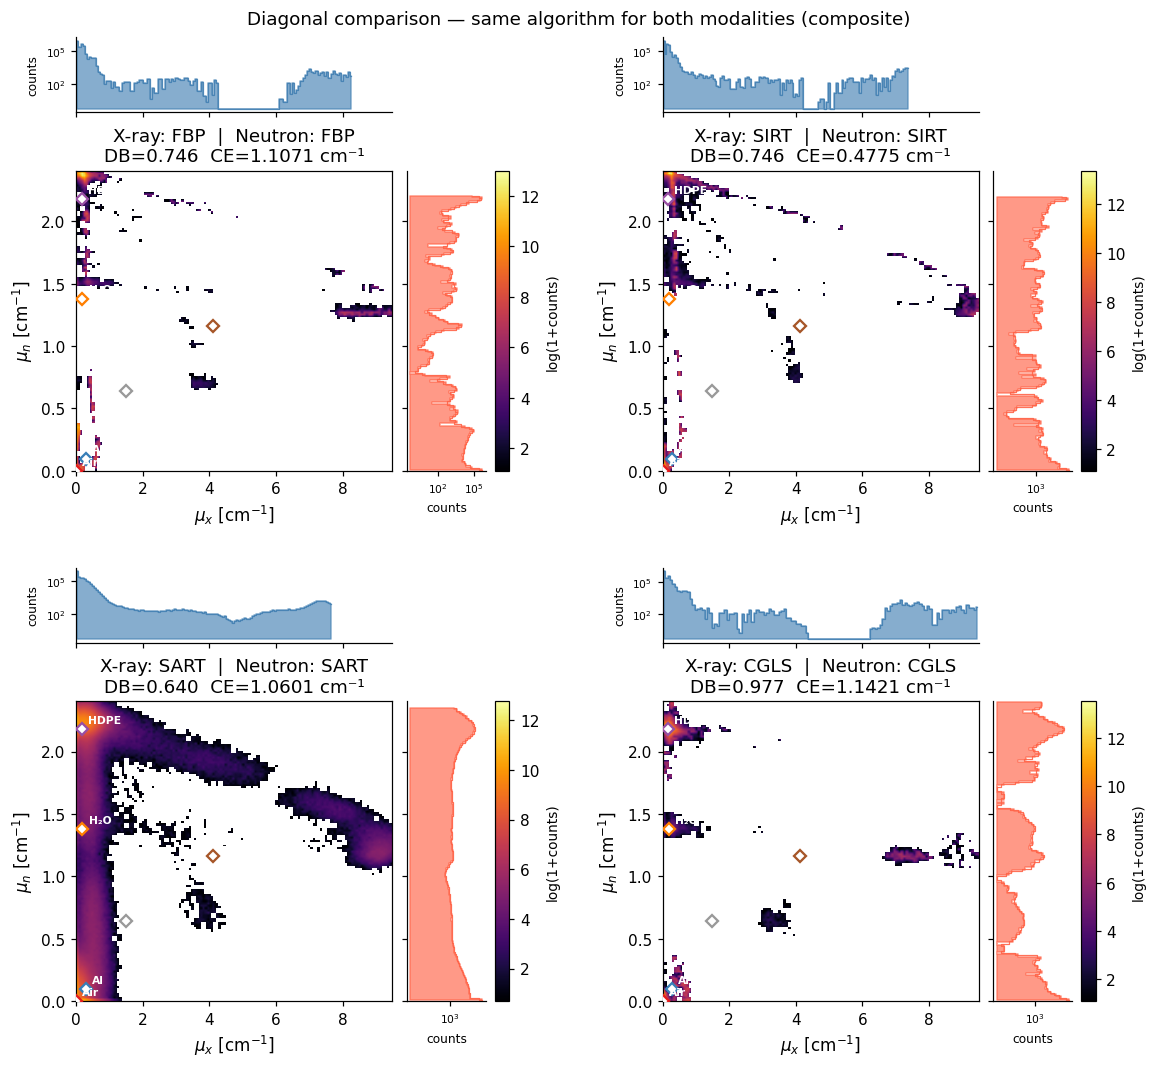

Saved output_grids/cross_alg_diagonal.png


In [10]:
# ── Diagonal comparison: same algorithm for both modalities ───────────────
diagonal_pairs = [(alg, alg) for alg in GRID_ALGORITHMS]

fig_diag, hists_diag = plot_cross_algorithm_grid(
    phantom         = phantom,
    xray_sinos      = x_sinos,
    neutron_sinos   = n_sinos,
    algorithm_pairs = diagonal_pairs,
    show_marginals  = True,
    show_gt_markers = True,
    show_metrics    = True,
    ncols           = 2,
    suptitle        = f'Diagonal comparison — same algorithm for both modalities ({PRESET})',
)
fig_diag.savefig('output_grids/cross_alg_diagonal.png',
                 dpi=150, bbox_inches='tight')
plt.show()
print('Saved output_grids/cross_alg_diagonal.png')


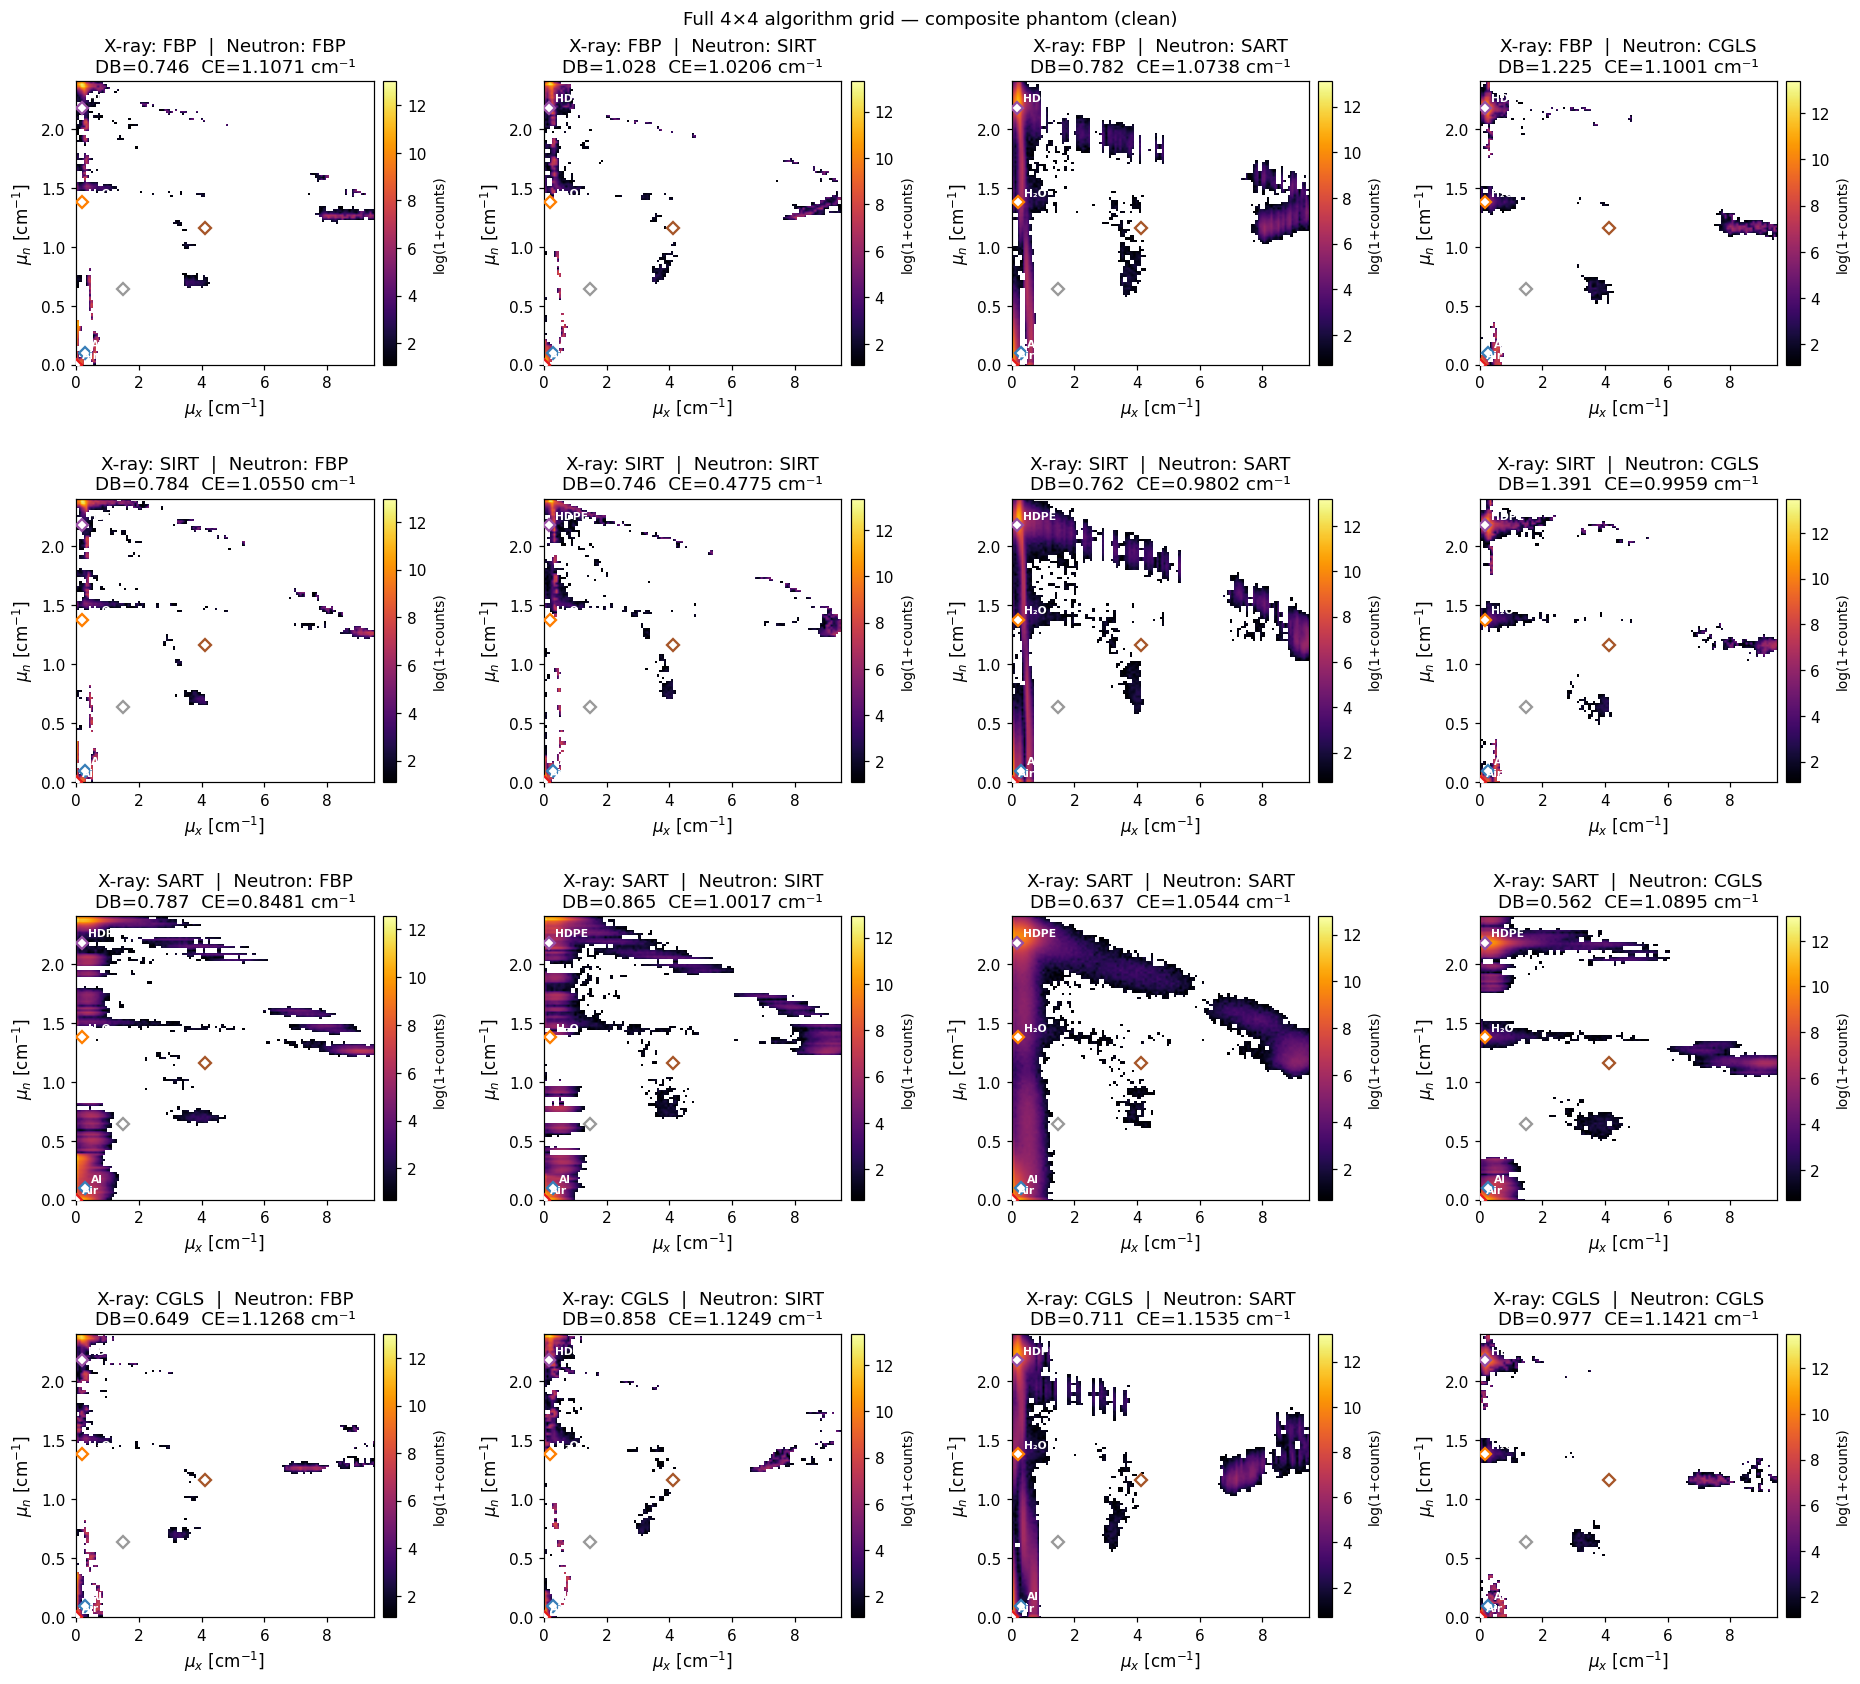

Saved output_grids/cross_alg_full_grid.png


In [11]:
# ── Full factorial 4×4 grid ────────────────────────────────────────────────
# Rows = X-ray algorithm, Columns = neutron algorithm.
full_pairs = [(ax, an) for ax in GRID_ALGORITHMS for an in GRID_ALGORITHMS]

fig_full, hists_full = plot_cross_algorithm_grid(
    phantom         = phantom,
    xray_sinos      = x_sinos,
    neutron_sinos   = n_sinos,
    algorithm_pairs = full_pairs,
    show_marginals  = False,   # compact layout for 4×4
    show_gt_markers = True,
    show_metrics    = True,
    ncols           = len(GRID_ALGORITHMS),
    figsize_per_panel = (4.2, 3.8),
    suptitle        = f'Full {len(GRID_ALGORITHMS)}×{len(GRID_ALGORITHMS)} algorithm grid — {PRESET} phantom (clean)',
)
fig_full.savefig('output_grids/cross_alg_full_grid.png',
                 dpi=150, bbox_inches='tight')
plt.show()
print('Saved output_grids/cross_alg_full_grid.png')


In [ ]:
# ── Custom selection: mixed pairs of interest ──────────────────────────────
custom_pairs = [
    ('FBP',  'FBP'),    # baseline analytic
    ('FBP',  'SIRT'),   # weak X-ray, strong neutron
    ('SIRT', 'FBP'),    # strong X-ray, weak neutron
    ('SIRT', 'SIRT'),   # both iterative
    ('SART', 'SART'),   # recommended pair
    ('SART', 'SIRT'),   # SART X-ray + SIRT neutron (SIRT sharper for H₂O/HDPE)
]

fig_custom, hists_custom = plot_cross_algorithm_grid(
    phantom         = phantom,
    xray_sinos      = x_sinos,
    neutron_sinos   = n_sinos,
    algorithm_pairs = custom_pairs,
    show_marginals  = True,
    show_metrics    = True,
    ncols           = 3,
    suptitle        = 'Selected cross-algorithm combinations — clean acquisition',
)
fig_custom.savefig('output_grids/cross_alg_custom.png',
                   dpi=150, bbox_inches='tight')
plt.show()
print('Saved output_grids/cross_alg_custom.png')


In [ ]:
# ── Repeat with artifacts injected ────────────────────────────────────────
noise_cfg = nxs.ArtifactConfig(photon_noise=True, I0_xray=5e4, I0_neutron=5e4)
x_sinos_noise, n_sinos_noise = make_cross_algorithm_sinos(
    phantom, GRID_ALGORITHMS, n_angles=N_ANGLES, cfg=noise_cfg,
)

fig_noise, _ = plot_cross_algorithm_grid(
    phantom, x_sinos_noise, n_sinos_noise, diagonal_pairs,
    show_metrics=True, ncols=2,
    suptitle='Diagonal comparison — moderate Poisson noise (I₀=5×10⁴)',
)
fig_noise.savefig('output_grids/cross_alg_noisy.png',
                  dpi=150, bbox_inches='tight')
plt.show()


---
## 13 · Cluster Quality Metrics & Algorithm Ranking  ★ new in v3


Three complementary metrics quantify bimodal histogram quality against
known ground-truth material positions.

| Metric | Symbol | Meaning | Better |
|--------|--------|---------|--------|
| Centroid error | CE_k | Distance of GMM centroid from GT position [cm⁻¹] | lower |
| Cluster spread | σ_x, σ_n | Std of cluster along each axis [cm⁻¹] | lower |
| Davies-Bouldin | DB | Separability index (compactness ÷ separation) | lower |

**`evaluate_histogram_quality(hist, phantom)`** returns all three.
**`compare_algorithms(results, phantom)`** tabulates them across a list
of `SimulationResult` objects.


In [ ]:
# ── Per-panel metrics for the cross-algorithm grid ─────────────────────────
print(f"\n{'X-ray alg':<10}  {'Neutron alg':<12}  {'DB':>8}  {'Mean CE [cm⁻¹]':>16}")
print('─' * 56)
grid_metric_rows = []
for (alg_x, alg_n), hist in hists_full.items():
    m = evaluate_histogram_quality(hist, phantom)
    print(f"{alg_x:<10}  {alg_n:<12}  {m.davies_bouldin:>8.4f}  {m.mean_centroid_error:>16.4f}")
    grid_metric_rows.append({'alg_x': alg_x, 'alg_n': alg_n,
                              'db': m.davies_bouldin,
                              'ce': m.mean_centroid_error})



X-ray alg   Neutron alg         DB    Mean CE [cm⁻¹]
────────────────────────────────────────────────────────
FBP         FBP             0.7458            1.1071


In [ ]:
# ── Heat-map of DB index across the algorithm grid ────────────────────────
import numpy as _np

n_alg = len(GRID_ALGORITHMS)
db_mat = _np.full((n_alg, n_alg), float('nan'))
ce_mat = _np.full((n_alg, n_alg), float('nan'))
for row in grid_metric_rows:
    i = GRID_ALGORITHMS.index(row['alg_x'])
    j = GRID_ALGORITHMS.index(row['alg_n'])
    db_mat[i, j] = row['db']
    ce_mat[i, j] = row['ce']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, mat, title, fmt in [
        (axes[0], db_mat, 'Davies-Bouldin index\n(lower = better)', '.3f'),
        (axes[1], ce_mat, 'Mean centroid error [cm⁻¹]\n(lower = better)', '.4f'),
]:
    im = ax.imshow(mat, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks(range(n_alg)); ax.set_xticklabels(GRID_ALGORITHMS)
    ax.set_yticks(range(n_alg)); ax.set_yticklabels(GRID_ALGORITHMS)
    ax.set_xlabel('Neutron algorithm'); ax.set_ylabel('X-ray algorithm')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    for i in range(n_alg):
        for j in range(n_alg):
            if not _np.isnan(mat[i, j]):
                ax.text(j, i, format(mat[i, j], fmt),
                        ha='center', va='center', fontsize=8,
                        color='white' if mat[i, j] > mat.max()*0.6 else 'black')
plt.tight_layout()
plt.savefig('output_grids/metric_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved output_grids/metric_heatmap.png')


In [ ]:
# ── compare_algorithms on the orchestrator results ─────────────────────────
# Run the clean scenario with four algorithms and compare in one table.

comparison_results = []
for alg in GRID_ALGORITHMS:
    sim_cmp = nxs.DualModalitySimulation(
        preset=PRESET, N=N, n_angles=N_ANGLES,
        algorithm=alg, verbose=False,
    )
    r = sim_cmp.run(nxs.ArtifactConfig.clean(), tag=alg)
    comparison_results.append(r)

metrics_cmp = compare_algorithms(
    comparison_results, phantom=phantom, print_table=True
)


In [ ]:
# ── Per-material centroid errors for the best and worst algorithm ──────────
best_alg  = min(metrics_cmp, key=lambda k: metrics_cmp[k].davies_bouldin)
worst_alg = max(metrics_cmp, key=lambda k: metrics_cmp[k].davies_bouldin)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, alg in zip(axes, [best_alg, worst_alg]):
    m    = metrics_cmp[alg]
    mats = list(m.centroid_errors.keys())
    errs = [m.centroid_errors[mat] for mat in mats]
    sx   = [m.sigma_x.get(mat, 0) for mat in mats]
    sn   = [m.sigma_n.get(mat, 0) for mat in mats]
    x    = range(len(mats))
    ax.bar(x, errs, color='steelblue', alpha=0.8, label='Centroid error')
    ax.errorbar(x, errs, yerr=[sx, sn], fmt='none', color='black',
                capsize=4, lw=1.5, label='σ_x / σ_n')
    ax.set_xticks(list(x)); ax.set_xticklabels(mats, rotation=30, ha='right')
    ax.set_ylabel('cm⁻¹'); ax.set_title(f'{alg}  (DB={m.davies_bouldin:.3f})')
    ax.legend(); ax.grid(True, alpha=0.3)
fig.suptitle('Per-material centroid errors: best vs worst algorithm', fontsize=11)
plt.tight_layout()
plt.savefig('output_grids/centroid_errors.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 14 · Save Figures


In [ ]:
import os
os.makedirs('output_figures', exist_ok=True)

save_map = [
    ('output_figures/comparison_grid.png',  sim.comparison_grid(all_results, ncols=3)),
    ('output_figures/slices_realistic.png',  r_real.plot_slices()),
    ('output_figures/histogram_realistic.png', r_real.plot_histogram(show_marginals=True)),
]

for path, fig_obj in save_map:
    fig_obj.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig_obj)
    print(f'Saved {path}')


In [ ]:
# ── Save numpy arrays ─────────────────────────────────────────────────────
os.makedirs('output_volumes', exist_ok=True)

for tag, r in [('clean', r_clean), ('noise', r_noise),
                ('scatter', r_scatter), ('realistic', r_real)]:
    np.save(f'output_volumes/vol_xray_{tag}.npy',    r.vol_xray)
    np.save(f'output_volumes/vol_neutron_{tag}.npy', r.vol_neutron)
    print(f'Saved vol_xray_{tag}.npy + vol_neutron_{tag}.npy')

print('\nAll outputs saved.')
